In [5]:
#CELL1
import os
import sys
import traci
import random
import numpy as np
import collections
import pickle
import matplotlib.pyplot as plt

# Check for SUMO_HOME environment variable
if 'SUMO_HOME' in os.environ:
    tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
    sys.path.append(tools)
else:
    sys.exit("please declare environment variable 'SUMO_HOME'")
    
print("SUMO environment configured successfully.")

SUMO environment configured successfully.


In [6]:
class QLearningAgent:
    """
    The Q-Learning agent with tuned hyperparameters for more aggressive learning.
    """
    def __init__(self, action_space, 
                 learning_rate=0.5,           #<-- INCREASED
                 discount_factor=0.95,          #<-- INCREASED
                 exploration_rate=1.0, 
                 exploration_decay=0.98):     #<-- INCREASED (Faster Decay)
        self.action_space = action_space
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = exploration_rate
        self.epsilon_min = 0.05
        self.epsilon_decay = exploration_decay
        self.q_table = collections.defaultdict(lambda: np.zeros(len(action_space)))

    # (The rest of the class functions: choose_action, learn, decay_epsilon, remain the same)
    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.action_space)
        else:
            return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        old_value = self.q_table[state][action]
        next_max = np.max(self.q_table[next_state])
        new_value = (1 - self.alpha) * old_value + self.alpha * (reward + self.gamma * next_max)
        self.q_table[state][action] = new_value

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [7]:
def get_state(traffic_light_id):
    """
    Gets a discretized state of the intersection to make learning easier.
    """
    lanes_to_monitor = {
        "north": ["MainN_to_I1_0", "MainN_to_I1_1"],
        "south": ["I2_to_I1_0", "I2_to_I1_1"],
        "west": ["SideW_to_I1_0"]
    }
    
    state = []
    for direction in ["north", "south", "west"]:
        total_queue = sum(traci.lane.getLastStepHaltingNumber(lane) for lane in lanes_to_monitor[direction])
        
        # Discretize queue length: 0=low, 1=medium, 2=high
        if total_queue < 5:
            state.append(0)
        elif total_queue < 15: # Increased the threshold for "medium"
            state.append(1)
        else:
            state.append(2)
            
    return tuple(state)

def run_episode(agent, episode_seed, traffic_light_id, action_map):
    """
    Runs a single episode with a longer minimum green time to prevent thrashing.
    """
    sumo_command = [
        "sumo-gui",
        "--start",          # Automatically start the simulation
        "--quit-on-end",    # Automatically close the GUI when done
        "-c", "attingal.sumocfg", 
        "--seed", str(episode_seed), 
        "--no-warnings", "true"
    ]
    traci.start(sumo_command)
    
    total_reward = 0

    # Lanes leading TO the intersection we are controlling
    incoming_lanes = [
        "MainN_to_I1_0", "MainN_to_I1_1", 
        "I2_to_I1_0", "I2_to_I1_1", 
        "SideW_to_I1_0"
    ]

    while traci.simulation.getTime() < 3600:
        state = get_state(traffic_light_id)
        action_index = agent.choose_action(state)
        
        phase_to_set = action_map[action_index]
        traci.trafficlight.setPhase(traffic_light_id, phase_to_set)
        
        # --- LONGER ACTION DURATION ---
        # Let simulation run for 20 seconds to see the effect of the action
        # This forces the agent to commit to its decision.
        for _ in range(20):
            traci.simulationStep()
        
        # --- REFINED REWARD LOGIC ---
        # The reward is the negative of the waiting time on ONLY the incoming lanes.
        # This gives a cleaner signal to the agent.
        reward = -sum(traci.lane.getWaitingTime(lane) for lane in incoming_lanes)
        
        next_state = get_state(traffic_light_id)
        
        agent.learn(state, action_index, reward, next_state)
        
        total_reward += reward
    
    traci.close()
    return total_reward

In [8]:
#CELL4
from tqdm.notebook import tqdm
import pickle
import os

# --- Configuration ---
NUM_EPISODES = 300 # Let's set a higher number for proper training
Q_TABLE_FILE = "q_table.pkl"
TRAFFIC_LIGHT_ID = "intersection_north"

# ACTION SPACE: 0 for N-S Green, 1 for West Green
action_space = [0, 1]
action_map = {0: 0, 1: 2}

# --- Training ---
agent = QLearningAgent(action_space)
rewards_per_episode = []

# --- CORRECTED LOADING LOGIC ---
# This safely loads the data without overwriting the defaultdict
if os.path.exists(Q_TABLE_FILE):
    with open(Q_TABLE_FILE, 'rb') as f:
        loaded_dict = pickle.load(f)
    agent.q_table.update(loaded_dict)
    print("Q-table loaded successfully. Resuming training.")

# Main training loop
for episode in tqdm(range(NUM_EPISODES), desc="Training Episodes"):
    episode_seed = 42 + episode
    total_reward = run_episode(agent, episode_seed, TRAFFIC_LIGHT_ID, action_map)
    rewards_per_episode.append(total_reward)
    agent.decay_epsilon()
    
    print(f"Episode {episode + 1}/{NUM_EPISODES}: Total Reward = {total_reward:.2f}, Epsilon = {agent.epsilon:.4f}")

    # Periodic backup save
    if (episode + 1) % 10 == 0:
        with open(Q_TABLE_FILE, 'wb') as f:
            pickle.dump(dict(agent.q_table), f)
        print(f"\nBackup Q-table saved at episode {episode + 1}")

print("Training finished.")

# Final Save
print("Saving final Q-table...")
with open(Q_TABLE_FILE, 'wb') as f:
    pickle.dump(dict(agent.q_table), f)
print(f"Final Q-table saved successfully to '{Q_TABLE_FILE}'")

Training Episodes:   0%|          | 0/300 [00:00<?, ?it/s]

TraCIException: Connection 'default' is already active.

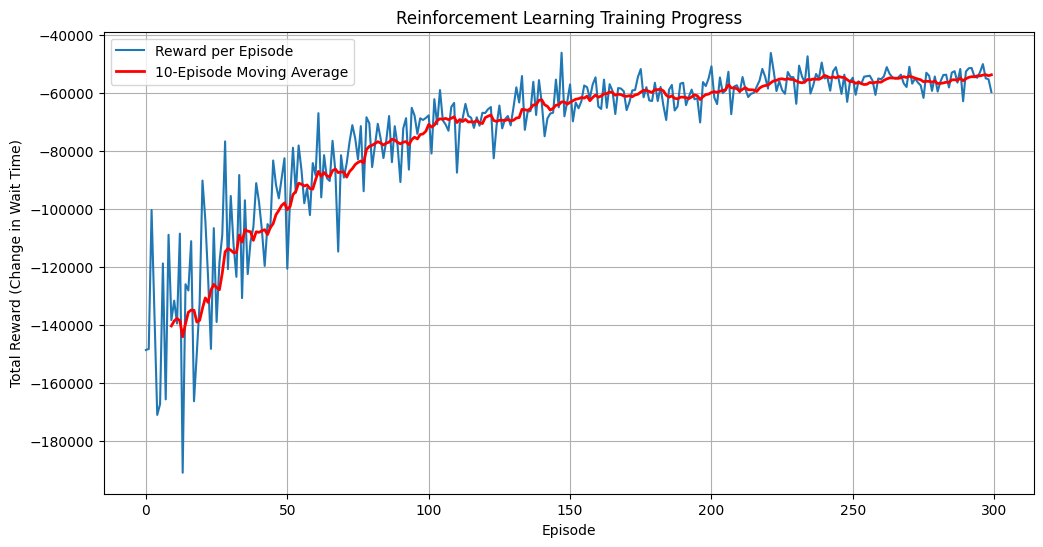

The plot shows the total reward collected in each episode.
A higher reward is better. An upward trend means the agent is learning!


In [ ]:
#CELL5
plt.figure(figsize=(12, 6))
plt.plot(rewards_per_episode, label='Reward per Episode')
plt.title('Reinforcement Learning Training Progress')
plt.xlabel('Episode')
plt.ylabel('Total Reward (Change in Wait Time)')
plt.grid(True)

# Add a moving average to see the trend more clearly
if len(rewards_per_episode) >= 10:
    moving_avg = np.convolve(rewards_per_episode, np.ones(10)/10, mode='valid')
    plt.plot(np.arange(len(moving_avg)) + 9, moving_avg, label='10-Episode Moving Average', color='red', linewidth=2)

plt.legend()
plt.show()

print("The plot shows the total reward collected in each episode.")
print("A higher reward is better. An upward trend means the agent is learning!")